# Elastic Net

In [ ]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
from sklearn import svm

## Alpha=0.0001

In [ ]:
df=pd.read_csv("Alpha00001Beta05.csv", sep="\t")

In [ ]:
df.shape

(3396, 4200)

In [ ]:
df.head()

,exm2264981-0_T_F_1984844725_1,exm1312-0_T_F_1919180959_2,exm1646-0_T_F_1921336671_0,exm1646-0_T_F_1921336671_2,exm1909-0_T_F_1919142595_2,exm3098-0_T_R_1919138216_2,exm4691-0_T_R_1921404998_1,exm4691-0_T_R_1921404998_2,exm2268641-0_T_R_1984844486_1,exm-rs734999-131_T_R_1990493843_0,...,exm-rs3905-131_T_R_1990492020_0,exm-rs3905-131_T_R_1990492020_1,exm1667844-0_T_R_1918599412_0,exm1667844-0_T_R_1918599412_2,exm-rs13303755-131_T_R_1990488488_1,exm-rs34173183-131_T_F_1990491693_1,exm2216437-0_T_F_1955482574_2,exm-rs41378955-132_T_F_1990486729_0,exm-rs41378955-132_T_F_1990486729_2,Smoking_status
0,0,0,0,1,1,1,1,0,0,1,...,1,0,0,1,0,0,1,0,1,0
1,0,1,0,1,1,1,0,0,1,0,...,1,0,0,1,0,0,1,0,1,1
2,1,0,0,0,1,0,1,0,0,1,...,1,0,0,1,0,0,1,0,1,1
3,1,1,0,0,1,1,1,0,0,1,...,1,0,0,1,0,0,1,1,0,0
4,0,1,0,0,1,1,1,0,1,1,...,1,0,0,1,0,0,1,1,0,1


In [ ]:
scaled_features = df.iloc[:, :-1]

labels=df.iloc[:, -1]

# Diviser les données en ensembles d'entraînement et de test
train_features, test_features, train_labels, test_labels = train_test_split(scaled_features, labels, test_size=0.2, random_state=42)

In [ ]:
model_LR=LogisticRegression(max_iter=10000, random_state=42)
model_LR.fit(train_features, train_labels)

# Prédire les labels pour l'ensemble de test
predictions = model_LR.predict(test_features)
# Calculer l'accuracy
accuracy = accuracy_score(test_labels, predictions)
print("Accuracy of Logistic Regression:", accuracy)

Accuracy of Logistic Regression: 0.9411764705882353


In [ ]:
# Calculer la précision
precision_LR = precision_score(test_labels, predictions, average='macro')
print("Precision Logistic Regression:", precision_LR)
# Calculer le rappel
recall_LR = recall_score(test_labels, predictions, average='macro')
print("Recall Logistic Regression:", recall_LR)
# Calculer le F1-score
f1_LR = f1_score(test_labels, predictions, average='macro')
print("F1-Score Logistic Regression:", f1_LR)

Precision Logistic Regression: 0.9406385576598343
Recall Logistic Regression: 0.9418629894320028
F1-Score Logistic Regression: 0.9410459148286863


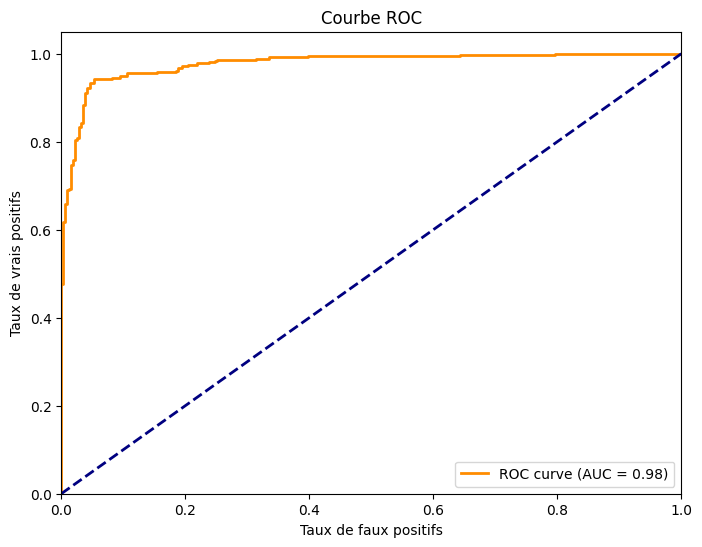

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Prédisez les probabilités des classes pour l'ensemble de test
y_score = model_LR.predict_proba(test_features)[:, 1]

# Calculez la courbe ROC
fpr, tpr, thresholds = roc_curve(test_labels, y_score)
roc_auc = auc(fpr, tpr)

# Tracez la courbe ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.title('Courbe ROC')
plt.legend(loc='lower right')
plt.show()

In [ ]:
from sklearn.linear_model import ElasticNet

In [ ]:
model_en = ElasticNet(alpha=0.0000000000001, l1_ratio=0.5, random_state=42)
model_en.fit(train_features, train_labels)

ElasticNet(alpha=1e-13, random_state=42)

In [ ]:
# Faire des prédictions sur les données de test
predictions = model_en.predict(test_features)
predictions = predictions.astype("int")

# Calculer l'exactitude du modèle
accuracy = accuracy_score(test_labels, predictions)
print(f"Accuracy of the Elastic Net model: {accuracy}")

Accuracy of the Elastic Net model: 0.6882352941176471


In [ ]:
# Créer et entraîner le modèle SVM
model_SVM = svm.SVC(probability=True, random_state=42)
model_SVM.fit(train_features, train_labels)
print ("SVM fiting is OK")

# Prédire les labels pour l'ensemble de test
predictions_SVM = model_SVM.predict(test_features)
# Calculer l'accuracy
accuracy_SVM = accuracy_score(test_labels, predictions_SVM)
print("Accuracy SVM:", accuracy_SVM)

# Calculer la précision
precision_SVM = precision_score(test_labels, predictions_SVM, average='macro')
print("Precision SVM:", precision_SVM)

# Calculer le rappel
recall_SVM = recall_score(test_labels, predictions_SVM, average='macro')
print("Recall SVM:", recall_SVM)

# Calculer le F1-score
f1_SVM = f1_score(test_labels, predictions_SVM, average='macro')
print("F1-Score SVM:", f1_SVM)

SVM fiting is OK
Accuracy SVM: 0.8544117647058823
Precision SVM: 0.8562874770371911
Recall SVM: 0.8570454762545698
F1-Score SVM: 0.8543963352517892


SVM withy lenear kernel

In [ ]:
# Créer et entraîner le modèle SVM
model_SVM_linear = svm.SVC(kernel = "linear", probability=True, random_state=42)
model_SVM_linear.fit(train_features, train_labels)
print ("SVM fiting is OK")

# Prédire les labels pour l'ensemble de test
predictions_SVM = model_SVM_linear.predict(test_features)
# Calculer l'accuracy
accuracy_SVM = accuracy_score(test_labels, predictions_SVM)
print("Accuracy SVM:", accuracy_SVM)

# Calculer la précision
precision_SVM = precision_score(test_labels, predictions_SVM, average='macro')
print("Precision SVM:", precision_SVM)

# Calculer le rappel
recall_SVM = recall_score(test_labels, predictions_SVM, average='macro')
print("Recall SVM:", recall_SVM)

# Calculer le F1-score
f1_SVM = f1_score(test_labels, predictions_SVM, average='macro')
print("F1-Score SVM:", f1_SVM)

SVM fiting is OK
Accuracy SVM: 0.9102941176470588
Precision SVM: 0.9098958333333333
Recall SVM: 0.9100417683376896
F1-Score SVM: 0.9099668127426913


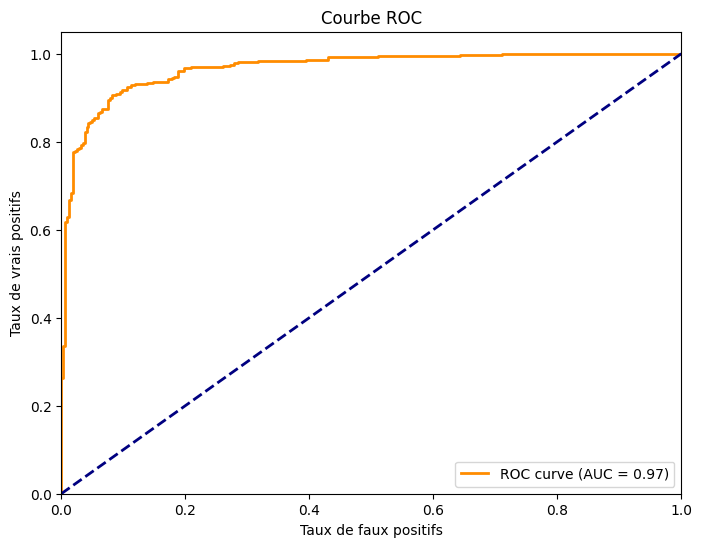

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Prédisez les probabilités des classes pour l'ensemble de test
y_score = model_SVM_linear.predict_proba(test_features)[:, 1]

# Calculez la courbe ROC
fpr, tpr, thresholds = roc_curve(test_labels, y_score)
roc_auc = auc(fpr, tpr)

# Tracez la courbe ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.title('Courbe ROC')
plt.legend(loc='lower right')
plt.show()

In [ ]:
from sklearn.feature_selection import SelectKBest, SelectPercentile, chi2
from sklearn.metrics import roc_curve, auc, roc_auc_score

<ipython-input-42-85f15c78ceb3>:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_data['Smoking_status'] = train_labels  # Add the target variable back to the new dataset if needed
<ipython-input-42-85f15c78ceb3>:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_data['Smoking_status'] = train_labels  # Add the target variable back to the new dataset if needed
<ipython-input-42-85f15c78ceb3>:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc

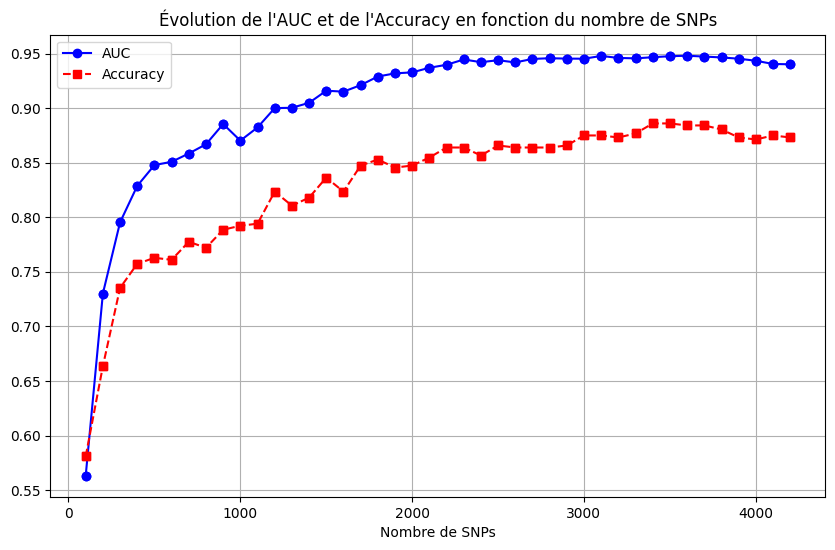

In [ ]:
# Nombre total de SNPs
total_snps = 4199

# Pas pour parcourir les SNPs
step = 100

# Listes pour stocker le nombre de SNPs et les AUC correspondants
num_snps = []
auc_scores = []
accuracy_scores = []

# Parcours des SNPs par pas de 1000
for i in range(1, total_snps, step):
  scaled_features = df.iloc[:, :-1]
  labels=df.iloc[:, -1]
  # Diviser les données en ensembles d'entraînement et de test
  train_features, test_features, train_labels, test_labels = train_test_split(scaled_features, labels, test_size=0.2, random_state=42)

  # Create a SelectKBest feature selector and specify the number of features to select
  num_features_to_select = i  # Specify the desired number of features
  selector = SelectKBest(chi2, k=num_features_to_select)

  # Fit the selector on the training data and transform the data to select the top-k features
  X_train_selected = selector.fit_transform(train_features, train_labels)
  X_test_selected = selector.transform(test_features)

  # Create a new DataFrame with the selected features
  selected_features = scaled_features.columns[selector.get_support()]
  new_data = train_features[selected_features]

  # Now, 'new_data' contains only the selected features, and you can save it as a new dataset
  new_data['Smoking_status'] = train_labels  # Add the target variable back to the new dataset if needed

  scaled_features = new_data.iloc[:, :-1]

  labels=new_data.iloc[:, -1]

  # Diviser les données en ensembles d'entraînement et de test
  train_features, test_features, train_labels, test_labels = train_test_split(scaled_features, labels, test_size=0.2, random_state=42)

  # Créez un modèle de régression logistique
  model_LR = LogisticRegression(max_iter=10000, random_state=42)
  model_LR.fit(train_features, train_labels)

  # Prédisez les probabilités des classes
  y_score = model_LR.predict_proba(test_features)[:, 1]

  # Calculez l'AUC
  auc = roc_auc_score(test_labels, y_score)

  # Calculez l'accuracy
  predictions = model_LR.predict(test_features)
  # Calculer l'accuracy
  accuracy = accuracy_score(test_labels, predictions)

  # Enregistrez le nombre de SNPs, l'AUC et l'accuracy correspondants
  num_snps.append(i + step)
  auc_scores.append(auc)
  accuracy_scores.append(accuracy)

  # Enregistrez le nombre de SNPs, l'AUC et l'accuracy correspondants
  num_snps.append(i+step)
  auc_scores.append(auc)
  accuracy_scores.append(accuracy)

# Créez une figure avec une seule échelle des ordonnées pour l'AUC et l'accuracy
plt.figure(figsize=(10, 6))

# Tracer la courbe de l'AUC
plt.plot(num_snps, auc_scores, marker='o', linestyle='-', color='b', label='AUC')

# Tracer la courbe de l'accuracy
plt.plot(num_snps, accuracy_scores, marker='s', linestyle='--', color='r', label='Accuracy')

# Titre et légendes
plt.title('Évolution de l\'AUC et de l\'Accuracy en fonction du nombre de SNPs')
plt.xlabel('Nombre de SNPs')
plt.grid(True)
plt.legend()

# Afficher le graphique
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
# Créer et entraîner le modèle DecisionTreeClassifier
model_DTC = DecisionTreeClassifier(random_state=42)
model_DTC.fit(train_features, train_labels)

# Prédisez les probabilités des classes
y_score = model_DTC.predict_proba(test_features)[:, 1]

In [ ]:
# Calculer l'accuracy
accuracy_DTC = accuracy_score(test_labels, y_score)
print("Accuracy SVM:", accuracy_DTC)

# Calculer la précision
precision_DTC = precision_score(test_labels, y_score, average='macro')
print("Precision SVM:", precision_DTC)

# Calculer le rappel
recall_DTC = recall_score(test_labels, y_score, average='macro')
print("Recall SVM:", recall_DTC)

# Calculer le F1-score
f1_DTC = f1_score(test_labels, y_score, average='macro')
print("F1-Score SVM:", f1_DTC)

Accuracy SVM: 0.5235294117647059
Precision SVM: 0.5247463852864481
Recall SVM: 0.5248048350541425
F1-Score SVM: 0.5234634551495017


## Alpha = 0.001

In [ ]:
df=pd.read_csv("Alpha0001Beta05.csv", sep="\t")

In [ ]:
df.shape

(3396, 3169)

In [ ]:
df.head()

,exm1646-0_T_F_1921336671_0,exm2062-0_B_R_1919120138_1,exm3098-0_T_R_1919138216_2,exm4691-0_T_R_1921404998_1,exm4691-0_T_R_1921404998_2,exm2268641-0_T_R_1984844486_1,exm-rs734999-131_T_R_1990493843_0,exm6852-0_T_F_2060141982_1,exm7551-0_T_R_1921491574_1,exm2264794-0_T_F_1984845543_1,...,exm-rs766420-131_T_F_1990494081_0,exm2273221-0_T_R_1984849351_0,exm2273222-0_T_R_1984849085_1,exm2263291-0_T_F_1975249882_2,exm-rs7892855-131_T_F_1990494318_2,exm2263220-0_T_R_1975252237_1,exm1667677-0_T_F_1918599131_1,exm-rs9786537-131_T_R_1990495083_2,exm-rs13303755-131_T_R_1990488488_1,Smoking_status
0,0,1,1,1,0,0,1,0,1,0,...,1,0,1,1,1,0,0,1,0,0
1,0,0,1,0,0,1,0,0,1,1,...,1,1,1,1,0,0,0,0,0,1
2,0,0,0,1,0,0,1,0,0,1,...,1,0,1,1,0,0,0,1,0,1
3,0,0,1,1,0,0,1,1,1,0,...,1,0,0,1,0,0,0,1,0,0
4,0,0,1,1,0,1,1,1,0,0,...,0,0,1,1,1,0,0,1,0,1


In [ ]:
scaled_features = df.iloc[:, :-1]
labels=df.iloc[:, -1]

# Diviser les données en ensembles d'entraînement et de test
train_features, test_features, train_labels, test_labels = train_test_split(scaled_features, labels, test_size=0.2, random_state=42)

In [ ]:
model_LR=LogisticRegression(max_iter=10000, random_state=42)
model_LR.fit(train_features, train_labels)

# Prédire les labels pour l'ensemble de test
predictions = model_LR.predict(test_features)
# Calculer l'accuracy
accuracy = accuracy_score(test_labels, predictions)
print("Accuracy of Logistic Regression:", accuracy)

Accuracy of Logistic Regression: 0.975


In [ ]:
# Calculer la précision
precision_LR = precision_score(test_labels, predictions, average='macro')
print("Precision Logistic Regression:", precision_LR)
# Calculer le rappel
recall_LR = recall_score(test_labels, predictions, average='macro')
print("Recall Logistic Regression:", recall_LR)
# Calculer le F1-score
f1_LR = f1_score(test_labels, predictions, average='macro')
print("F1-Score Logistic Regression:", f1_LR)

Precision Logistic Regression: 0.9746955133765919
Recall Logistic Regression: 0.9751777976536788
F1-Score Logistic Regression: 0.9749174946135537


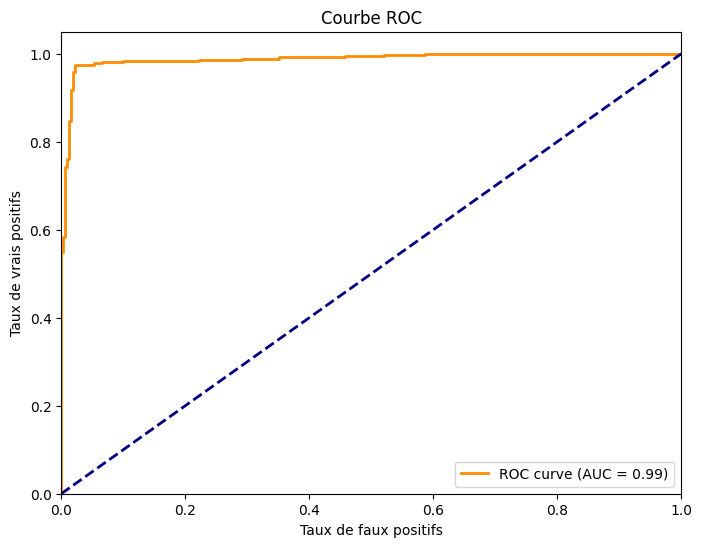

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Prédisez les probabilités des classes pour l'ensemble de test
y_score = model_LR.predict_proba(test_features)[:, 1]

# Calculez la courbe ROC
fpr, tpr, thresholds = roc_curve(test_labels, y_score)
roc_auc = auc(fpr, tpr)

# Tracez la courbe ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.title('Courbe ROC')
plt.legend(loc='lower right')
plt.show()

In [ ]:
# Créer et entraîner le modèle SVM
model_SVM_linear = svm.SVC(kernel = "linear", probability=True, random_state=42)
model_SVM_linear.fit(train_features, train_labels)
print ("SVM fiting is OK")

# Prédire les labels pour l'ensemble de test
predictions_SVM = model_SVM_linear.predict(test_features)
# Calculer l'accuracy
accuracy_SVM = accuracy_score(test_labels, predictions_SVM)
print("Accuracy SVM:", accuracy_SVM)

# Calculer la précision
precision_SVM = precision_score(test_labels, predictions_SVM, average='macro')
print("Precision SVM:", precision_SVM)

# Calculer le rappel
recall_SVM = recall_score(test_labels, predictions_SVM, average='macro')
print("Recall SVM:", recall_SVM)

# Calculer le F1-score
f1_SVM = f1_score(test_labels, predictions_SVM, average='macro')
print("F1-Score SVM:", f1_SVM)

SVM fiting is OK
Accuracy SVM: 0.8573529411764705
Precision SVM: 0.8570390365448506
Recall SVM: 0.8583567068140571
F1-Score SVM: 0.8571598722321477


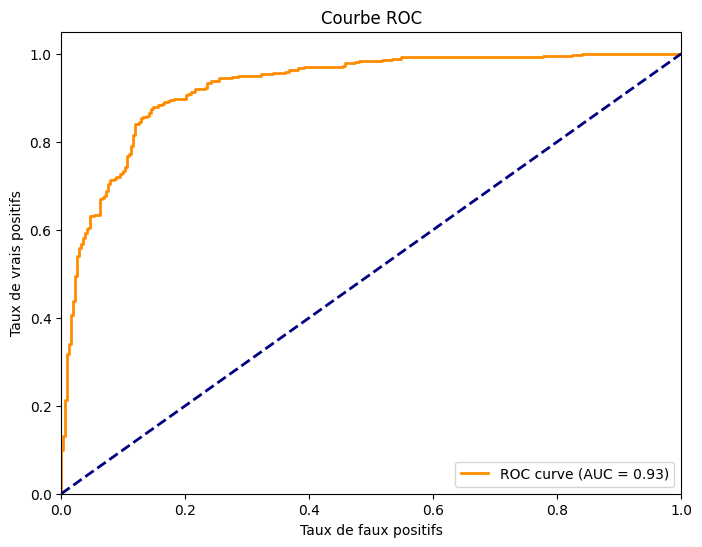

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Prédisez les probabilités des classes pour l'ensemble de test
y_score = model_SVM_linear.predict_proba(test_features)[:, 1]

# Calculez la courbe ROC
fpr, tpr, thresholds = roc_curve(test_labels, y_score)
roc_auc = auc(fpr, tpr)

# Tracez la courbe ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.title('Courbe ROC')
plt.legend(loc='lower right')
plt.show()

Accuracy: 0.5514705882352942


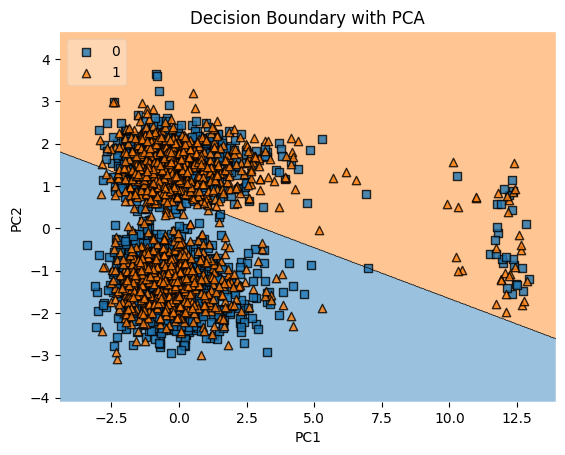

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from mlxtend.plotting import plot_decision_regions

# Séparation des features et des étiquettes
X = df.drop(columns=['Smoking_status'])
y = df['Smoking_status']

# Réduction de dimensionnalité avec PCA
pca = PCA(n_components=2)  # Réduire en 2 dimensions pour la visualisation
X_pca = pca.fit_transform(X)

# Diviser les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

# Entraîner le modèle de régression logistique sur les données projetées
model = LogisticRegression()
model.fit(X_train, y_train)

# Prédire les étiquettes sur l'ensemble de test
y_pred = model.predict(X_test)

# Calculer l'accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Tracer la courbe de décision dans l'espace de dimension réduite
plot_decision_regions(X_train, y_train.values, clf=model, legend=2)

# Afficher le graphique
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Decision Boundary with PCA')
plt.show()

## Alpha = 0.01

In [ ]:
df=pd.read_csv("Alpha001Beta05.csv", sep="\t")

In [ ]:
df.shape

(3396, 1223)

In [ ]:
df.head()

,exm1646-0_T_F_1921336671_2,exm3098-0_T_R_1919138216_2,exm7145-0_T_R_1921364544_2,exm7551-0_T_R_1921491574_1,exm-rs12741973-131_T_R_1990488294_1,exm13810-0_B_R_1919148338_0,exm13983-0_T_R_1921463936_2,exm14634-0_T_F_1919124801_2,exm15048-0_T_R_1919178408_2,exm21826-0_T_R_1921430014_1,...,exm1649435-0_T_R_1922087680_1,exm1653403-0_B_R_1922027060_1,exm2262922-0_T_F_1975259452_1,exm2268617-0_T_F_1984849086_2,exm1658059-0_B_R_1922080278_1,exm2273207-0_T_R_1984849299_2,exm2268560-0_T_F_1984848992_2,exm-rs766420-131_T_F_1990494081_0,exm2273221-0_T_R_1984849351_0,Smoking_status
0,1,1,1,1,1,1,1,1,0,1,...,0,0,0,0,0,1,0,1,0,0
1,1,1,1,1,1,1,1,1,0,0,...,0,0,0,1,0,1,0,1,1,1
2,0,0,1,0,1,0,0,1,1,0,...,0,0,0,0,0,1,1,1,0,1
3,0,1,1,1,0,1,1,1,1,1,...,0,0,0,0,0,1,1,1,0,0
4,0,1,0,0,0,1,0,0,1,0,...,1,1,0,0,1,0,0,0,0,1


In [ ]:
scaled_features = df.iloc[:, :-1]

labels=df.iloc[:, -1]

# Diviser les données en ensembles d'entraînement et de test
train_features, test_features, train_labels, test_labels = train_test_split(scaled_features, labels, test_size=0.2, random_state=42)

In [ ]:
model_LR=LogisticRegression(max_iter=10000, random_state=42)
model_LR.fit(train_features, train_labels)

# Prédire les labels pour l'ensemble de test
predictions = model_LR.predict(test_features)
# Calculer l'accuracy
accuracy = accuracy_score(test_labels, predictions)
print("Accuracy of Logistic Regression:", accuracy)

Accuracy of Logistic Regression: 0.9102941176470588


In [ ]:
# Calculer la précision
precision_LR = precision_score(test_labels, predictions, average='macro')
print("Precision Logistic Regression:", precision_LR)
# Calculer le rappel
recall_LR = recall_score(test_labels, predictions, average='macro')
print("Recall Logistic Regression:", recall_LR)
# Calculer le F1-score
f1_LR = f1_score(test_labels, predictions, average='macro')
print("F1-Score Logistic Regression:", f1_LR)

Precision Logistic Regression: 0.9097402597402597
Recall Logistic Regression: 0.9109535511770682
F1-Score Logistic Regression: 0.9101072947886937


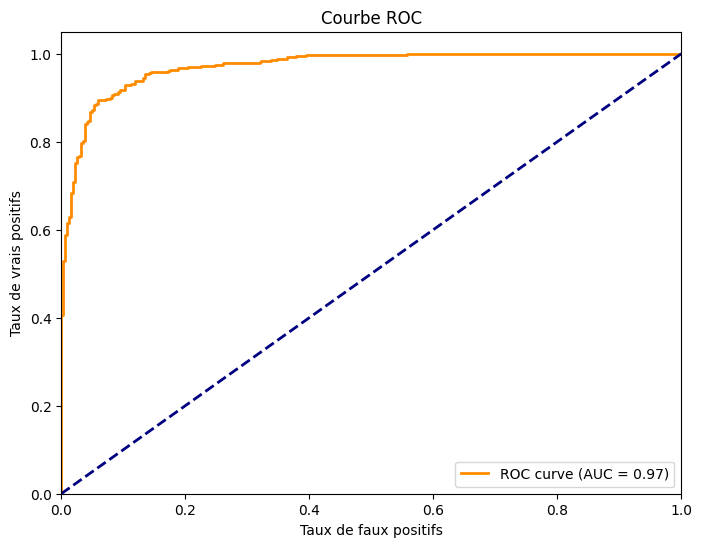

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Prédisez les probabilités des classes pour l'ensemble de test
y_score = model_LR.predict_proba(test_features)[:, 1]

# Calculez la courbe ROC
fpr, tpr, thresholds = roc_curve(test_labels, y_score)
roc_auc = auc(fpr, tpr)

# Tracez la courbe ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.title('Courbe ROC')
plt.legend(loc='lower right')
plt.show()

In [ ]:
# Créer et entraîner le modèle SVM
model_SVM_linear = svm.SVC(kernel = "linear", probability=True, random_state=42)
model_SVM_linear.fit(train_features, train_labels)
print ("SVM fiting is OK")

# Prédire les labels pour l'ensemble de test
predictions_SVM = model_SVM_linear.predict(test_features)
# Calculer l'accuracy
accuracy_SVM = accuracy_score(test_labels, predictions_SVM)
print("Accuracy SVM:", accuracy_SVM)

# Calculer la précision
precision_SVM = precision_score(test_labels, predictions_SVM, average='macro')
print("Precision SVM:", precision_SVM)

# Calculer le rappel
recall_SVM = recall_score(test_labels, predictions_SVM, average='macro')
print("Recall SVM:", recall_SVM)

# Calculer le F1-score
f1_SVM = f1_score(test_labels, predictions_SVM, average='macro')
print("F1-Score SVM:", f1_SVM)

SVM fiting is OK
Accuracy SVM: 0.8279411764705882
Precision SVM: 0.8272569444444444
Recall SVM: 0.8273734575673635
F1-Score SVM: 0.827313394932703


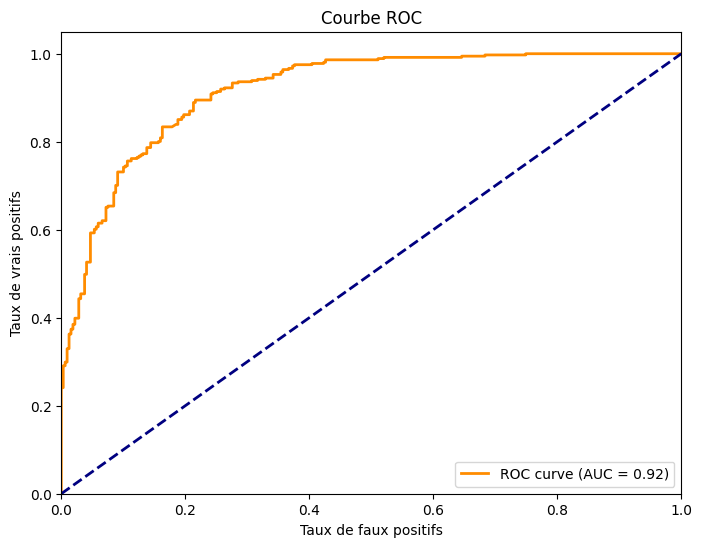

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Prédisez les probabilités des classes pour l'ensemble de test
y_score = model_SVM_linear.predict_proba(test_features)[:, 1]

# Calculez la courbe ROC
fpr, tpr, thresholds = roc_curve(test_labels, y_score)
roc_auc = auc(fpr, tpr)

# Tracez la courbe ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.title('Courbe ROC')
plt.legend(loc='lower right')
plt.show()

## Alpha = 0.1

In [ ]:
df=pd.read_csv("Alpha01Beta05.csv", sep="\t")

In [ ]:
df.shape

(3396, 1)

In [ ]:
df.head()

,Smoking_status
0,0
1,1
2,1
3,0
4,1


## ALpha = 0.5

In [ ]:
df=pd.read_csv("Alpha05Beta05.csv", sep="\t")

In [ ]:
df.shape

(3396, 1)

In [ ]:
df.head()

,Smoking_status
0,0
1,1
2,1
3,0
4,1


## Intersection des colonnes

In [ ]:
df1=pd.read_csv("Alpha001Beta05.csv", sep="\t")
df2=pd.read_csv("Alpha0001Beta05.csv", sep="\t")
df3=pd.read_csv("Alpha00001Beta05.csv", sep="\t")

In [ ]:
df1.shape

(3396, 1223)

In [ ]:
df2.shape

(3396, 3169)

In [ ]:
df3.shape

(3396, 4200)

In [ ]:
# Supposons que df1, df2, df3, df4 et df5 sont vos 5 DataFrames

# Créer un ensemble contenant les noms de colonnes de chaque DataFrame
columns_set1 = set(df1.columns)
columns_set2 = set(df2.columns)
columns_set3 = set(df3.columns)

# Trouver l'intersection des ensembles de noms de colonnes
common_columns = columns_set1.intersection(columns_set2, columns_set3)

# Compter le nombre de colonnes communes
num_common_columns = len(common_columns)

print("Nombre de colonnes communes à tous les 5 DataFrames :", num_common_columns)

Nombre de colonnes communes à tous les 5 DataFrames : 700


In [ ]:
# Sélectionner uniquement les colonnes communes dans chaque DataFrame
df1_common = df1.loc[:, common_columns]

<ipython-input-22-10db81f3d398>:2: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  df1_common = df1.loc[:, common_columns]


In [ ]:
# Récupérer les noms de colonnes sauf "Smoking_status"
columns_except_smoking = [col for col in df1_common.columns if col != "Smoking_status"]

# Réorganiser les colonnes avec "Smoking_status" à la fin
new_order = columns_except_smoking + ["Smoking_status"]

# Créer un nouveau DataFrame avec l'ordre de colonnes modifié
new_df = df1_common[new_order]

In [ ]:
new_df.head()

,exm2261464-0_T_F_1975260898_1,exm1537001-0_T_F_1922596323_0,exm1244963-0_T_F_1921680259_0,exm-rs7590720-131_T_F_1990494022_0,exm1125198-0_T_F_1922791349_1,exm1199401-0_T_F_2060138460_1,exm2270315-0_T_R_1984847795_2,exm2268810-0_T_R_1984845512_1,exm232921-0_B_F_1919015389_1,exm2249017-0_T_F_1975249026_2,...,exm259476-0_T_R_1918940960_2,exm-rs11249661-131_T_F_1990487609_2,exm2271097-0_T_R_1984851205_2,exm2265146-0_T_F_1984842999_0,exm7551-0_T_R_1921491574_1,exm1315705-0_T_R_1918703936_1,exm2264518-0_T_F_1984847007_0,exm928087-0_T_F_1918386921_2,exm-rs7782376-131_T_F_1990494246_0,Smoking_status
0,0,0,1,0,1,0,1,1,1,1,...,0,1,0,1,1,0,0,0,0,0
1,0,0,1,1,0,0,0,1,0,1,...,1,1,0,0,1,0,0,1,0,1
2,0,0,0,0,1,0,0,0,1,0,...,1,1,1,0,0,0,0,0,0,1
3,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
4,0,0,0,1,1,1,0,0,0,0,...,0,1,0,1,0,1,0,1,1,1


In [ ]:
new_df.shape

(3396, 700)

In [ ]:
new_df.to_csv("Intersection_699SNP.csv", sep="\t", index=False)

In [ ]:
new_df = pd.read_csv("Intersection_699SNP.csv", sep="\t")

In [ ]:
scaled_features = new_df.iloc[:, :-1]

labels=new_df.iloc[:, -1]

# Diviser les données en ensembles d'entraînement et de test
train_features, test_features, train_labels, test_labels = train_test_split(scaled_features, labels, test_size=0.2, random_state=42)

In [ ]:
model_LR=LogisticRegression(max_iter=10000, random_state=42)
model_LR.fit(train_features, train_labels)

# Prédire les labels pour l'ensemble de test
predictions = model_LR.predict(test_features)
# Calculer l'accuracy
accuracy = accuracy_score(test_labels, predictions)
print("Accuracy of Logistic Regression:", accuracy)

Accuracy of Logistic Regression: 0.8529411764705882


In [ ]:
# Calculer la précision
precision_LR = precision_score(test_labels, predictions, average='macro')
print("Precision Logistic Regression:", precision_LR)
# Calculer le rappel
recall_LR = recall_score(test_labels, predictions, average='macro')
print("Recall Logistic Regression:", recall_LR)
# Calculer le F1-score
f1_LR = f1_score(test_labels, predictions, average='macro')
print("F1-Score Logistic Regression:", f1_LR)

Precision Logistic Regression: 0.8534717715768981
Recall Logistic Regression: 0.8547486518639447
F1-Score Logistic Regression: 0.8528597147209527


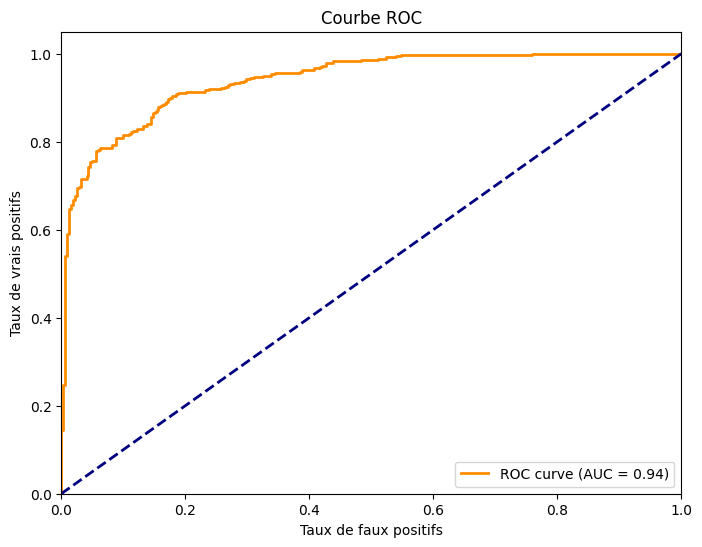

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Prédisez les probabilités des classes pour l'ensemble de test
y_score = model_LR.predict_proba(test_features)[:, 1]

# Calculez la courbe ROC
fpr, tpr, thresholds = roc_curve(test_labels, y_score)
roc_auc = auc(fpr, tpr)

# Tracez la courbe ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.title('Courbe ROC')
plt.legend(loc='lower right')
plt.show()

In [ ]:
# Créer et entraîner le modèle SVM
model_SVM_linear = svm.SVC(kernel = "linear", probability=True, random_state=42)
model_SVM_linear.fit(train_features, train_labels)
print ("SVM fiting is OK")

# Prédire les labels pour l'ensemble de test
predictions_SVM = model_SVM_linear.predict(test_features)
# Calculer l'accuracy
accuracy_SVM = accuracy_score(test_labels, predictions_SVM)
print("Accuracy SVM:", accuracy_SVM)

# Calculer la précision
precision_SVM = precision_score(test_labels, predictions_SVM, average='macro')
print("Precision SVM:", precision_SVM)

# Calculer le rappel
recall_SVM = recall_score(test_labels, predictions_SVM, average='macro')
print("Recall SVM:", recall_SVM)

# Calculer le F1-score
f1_SVM = f1_score(test_labels, predictions_SVM, average='macro')
print("F1-Score SVM:", f1_SVM)

SVM fiting is OK
Accuracy SVM: 0.8426470588235294
Precision SVM: 0.8441657427937916
Recall SVM: 0.8450533610052189
F1-Score SVM: 0.8426194900058184


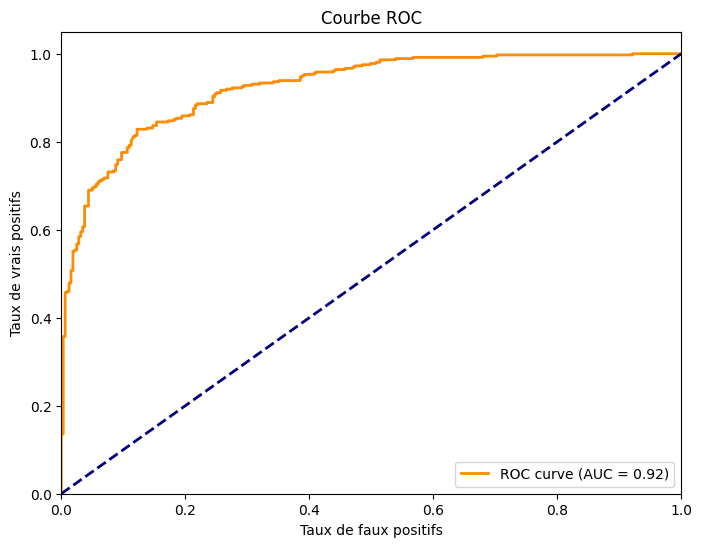

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Prédisez les probabilités des classes pour l'ensemble de test
y_score = model_SVM_linear.predict_proba(test_features)[:, 1]

# Calculez la courbe ROC
fpr, tpr, thresholds = roc_curve(test_labels, y_score)
roc_auc = auc(fpr, tpr)

# Tracez la courbe ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.title('Courbe ROC')
plt.legend(loc='lower right')
plt.show()

## Evolution des accuracy sur les 699 SNPs

<ipython-input-33-b955fd7cbd6f>:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_data['Smoking_status'] = labels  # Add the target variable back to the new dataset if needed
<ipython-input-33-b955fd7cbd6f>:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_data['Smoking_status'] = labels  # Add the target variable back to the new dataset if needed
<ipython-input-33-b955fd7cbd6f>:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer

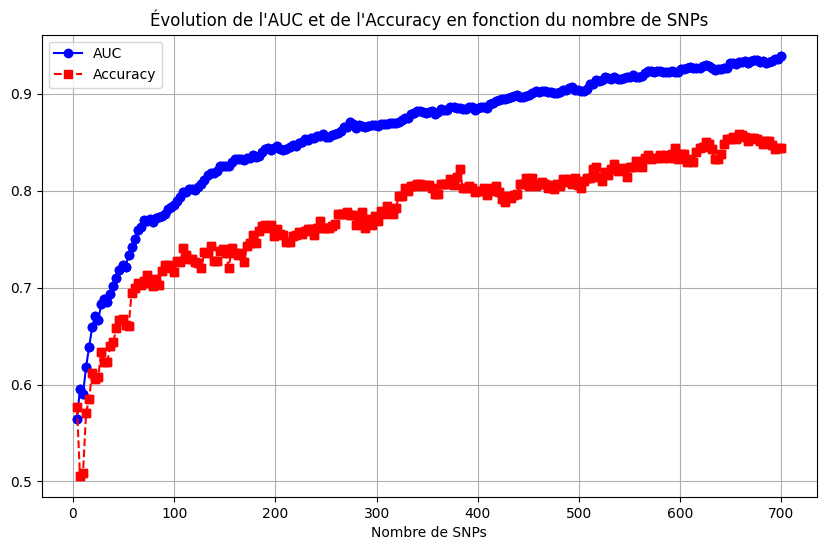

In [ ]:
from sklearn.feature_selection import SelectKBest, SelectPercentile, chi2
from sklearn.metrics import roc_auc_score, accuracy_score

# Nombre total de SNPs
total_snps = 699

# Pas pour parcourir les SNPs
step = 3

# Listes pour stocker le nombre de SNPs et les AUC correspondants
num_snps = []
auc_scores = []
accuracy_scores = []

# Parcours des SNPs par pas de 1000
for i in range(1, total_snps, step):
  #X = df.iloc[:, 2:]
  scaled_features = new_df.iloc[:, :-1]

  labels=new_df.iloc[:, -1]

  # Diviser les données en ensembles d'entraînement et de test
  # train_features, test_features, train_labels, test_labels = train_test_split(scaled_features, labels, test_size=0.2, random_state=42)

  # Create a SelectKBest feature selector and specify the number of features to select
  num_features_to_select = i  # Specify the desired number of features
  selector = SelectKBest(chi2, k=num_features_to_select)

  # Fit the selector on the training data and transform the data to select the top-k features
  X_train_selected = selector.fit_transform(scaled_features, labels)
  X_test_selected = selector.transform(scaled_features)

  # Create a new DataFrame with the selected features
  selected_features = scaled_features.columns[selector.get_support()]
  new_data = scaled_features[selected_features]

  # Now, 'new_data' contains only the selected features, and you can save it as a new dataset
  new_data['Smoking_status'] = labels  # Add the target variable back to the new dataset if needed

  scaled_features = new_data.iloc[:, :-1]

  labels=new_data.iloc[:, -1]

  # Diviser les données en ensembles d'entraînement et de test
  train_features, test_features, train_labels, test_labels = train_test_split(scaled_features, labels, test_size=0.2, random_state=42)

  # Créez un modèle de régression logistique
  model_LR = LogisticRegression(max_iter=10000, random_state=42)
  model_LR.fit(train_features, train_labels)

  # Prédisez les probabilités des classes
  y_score = model_LR.predict_proba(test_features)[:, 1]

  # Calculez l'AUC
  auc = roc_auc_score(test_labels, y_score)

  # Calculez l'accuracy
  predictions = model_LR.predict(test_features)
  # Calculer l'accuracy
  accuracy = accuracy_score(test_labels, predictions)

  # Enregistrez le nombre de SNPs, l'AUC et l'accuracy correspondants
  num_snps.append(i + step)
  auc_scores.append(auc)
  accuracy_scores.append(accuracy)

  # Enregistrez le nombre de SNPs, l'AUC et l'accuracy correspondants
  num_snps.append(i+step)
  auc_scores.append(auc)
  accuracy_scores.append(accuracy)

# Créez une figure avec une seule échelle des ordonnées pour l'AUC et l'accuracy
plt.figure(figsize=(10, 6))

# Tracer la courbe de l'AUC
plt.plot(num_snps, auc_scores, marker='o', linestyle='-', color='b', label='AUC')

# Tracer la courbe de l'accuracy
plt.plot(num_snps, accuracy_scores, marker='s', linestyle='--', color='r', label='Accuracy')

# Titre et légendes
plt.title('Évolution de l\'AUC et de l\'Accuracy en fonction du nombre de SNPs')
plt.xlabel('Nombre de SNPs')
plt.grid(True)
plt.legend()

# Afficher le graphique
plt.show()

In [ ]:
#X = df.iloc[:, 2:]
scaled_features = new_df.iloc[:, :-1]

labels=new_df.iloc[:, 1]

# Diviser les données en ensembles d'entraînement et de test
train_features, test_features, train_labels, test_labels = train_test_split(scaled_features, labels, test_size=0.2, random_state=42)

In [ ]:
# Create a SelectKBest feature selector and specify the number of features to select
num_features_to_select = 500  # Specify the desired number of features
selector = SelectKBest(chi2, k=num_features_to_select)

# Fit the selector on the training data and transform the data to select the top-k features
X_train_selected = selector.fit_transform(scaled_features, labels)
X_test_selected = selector.transform(scaled_features)

In [ ]:
# Create a new DataFrame with the selected features
selected_features = scaled_features.columns[selector.get_support()]
# Convert the 'selected_features' Index to a list
selected_features = selected_features.tolist()

# Append the string 'Smoking_status' to the list
selected_features.append("Smoking_status")
new_data = new_df[selected_features]

# Now, 'new_data' contains only the selected features, and you can save it as a new dataset
#new_data.loc[:, 'Smoking_status'] = labels
#new_data.to_csv('new_dataset.csv', index=False)  # Save the new dataset to a CSV file

In [ ]:
new_data.head()

,exm1537001-0_T_F_1922596323_0,exm1244963-0_T_F_1921680259_0,exm-rs7590720-131_T_F_1990494022_0,exm1125198-0_T_F_1922791349_1,exm1199401-0_T_F_2060138460_1,exm2270315-0_T_R_1984847795_2,exm2268810-0_T_R_1984845512_1,exm232921-0_B_F_1919015389_1,exm2249017-0_T_F_1975249026_2,exm2266455-0_T_F_1984840983_0,...,exm-rs2816316-131_T_R_1990490941_0,exm250297-0_T_R_1918916076_1,exm259476-0_T_R_1918940960_2,exm2271097-0_T_R_1984851205_2,exm2265146-0_T_F_1984842999_0,exm7551-0_T_R_1921491574_1,exm1315705-0_T_R_1918703936_1,exm2264518-0_T_F_1984847007_0,exm-rs7782376-131_T_F_1990494246_0,Smoking_status
0,0,1,0,1,0,1,1,1,1,1,...,0,1,0,0,1,1,0,0,0,0
1,0,1,1,0,0,0,1,0,1,0,...,0,0,1,0,0,1,0,0,0,1
2,0,0,0,1,0,0,0,1,0,0,...,0,0,1,1,0,0,0,0,0,1
3,0,0,1,0,0,0,0,0,0,1,...,0,0,0,0,0,1,0,0,1,0
4,0,0,1,1,1,0,0,0,0,0,...,0,0,0,0,1,0,1,0,1,1


In [ ]:
new_data.to_csv("500Best_SNP.csv", sep="\t", index=False)

In [ ]:
new_df.head()

,exm2261464-0_T_F_1975260898_1,exm1537001-0_T_F_1922596323_0,exm1244963-0_T_F_1921680259_0,exm-rs7590720-131_T_F_1990494022_0,exm1125198-0_T_F_1922791349_1,exm1199401-0_T_F_2060138460_1,exm2270315-0_T_R_1984847795_2,exm2268810-0_T_R_1984845512_1,exm232921-0_B_F_1919015389_1,exm2249017-0_T_F_1975249026_2,...,exm259476-0_T_R_1918940960_2,exm-rs11249661-131_T_F_1990487609_2,exm2271097-0_T_R_1984851205_2,exm2265146-0_T_F_1984842999_0,exm7551-0_T_R_1921491574_1,exm1315705-0_T_R_1918703936_1,exm2264518-0_T_F_1984847007_0,exm928087-0_T_F_1918386921_2,exm-rs7782376-131_T_F_1990494246_0,Smoking_status
0,0,0,1,0,1,0,1,1,1,1,...,0,1,0,1,1,0,0,0,0,0
1,0,0,1,1,0,0,0,1,0,1,...,1,1,0,0,1,0,0,1,0,1
2,0,0,0,0,1,0,0,0,1,0,...,1,1,1,0,0,0,0,0,0,1
3,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
4,0,0,0,1,1,1,0,0,0,0,...,0,1,0,1,0,1,0,1,1,1


In [ ]:
scaled_features = new_data.iloc[:, :-1]

labels=new_data.iloc[:, -1]

# Diviser les données en ensembles d'entraînement et de test
train_features, test_features, train_labels, test_labels = train_test_split(scaled_features, labels, test_size=0.2, random_state=42)

In [ ]:
model_LR=LogisticRegression(max_iter=10000, random_state=42)
model_LR.fit(train_features, train_labels)

# Prédire les labels pour l'ensemble de test
predictions = model_LR.predict(test_features)
# Calculer l'accuracy
accuracy = accuracy_score(test_labels, predictions)
print("Accuracy of Logistic Regression:", accuracy)

Accuracy of Logistic Regression: 0.825


In [ ]:
# Calculer la précision
precision_LR = precision_score(test_labels, predictions, average='macro')
print("Precision Logistic Regression:", precision_LR)
# Calculer le rappel
recall_LR = recall_score(test_labels, predictions, average='macro')
print("Recall Logistic Regression:", recall_LR)
# Calculer le F1-score
f1_LR = f1_score(test_labels, predictions, average='macro')
print("F1-Score Logistic Regression:", f1_LR)

Precision Logistic Regression: 0.8254083610188261
Recall Logistic Regression: 0.8266092967115033
F1-Score Logistic Regression: 0.8248905565978737


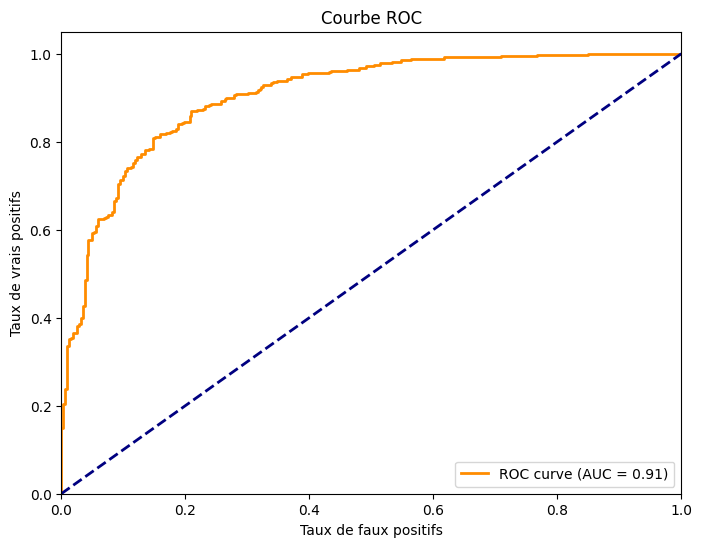

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Prédisez les probabilités des classes pour l'ensemble de test
y_score = model_LR.predict_proba(test_features)[:, 1]

# Calculez la courbe ROC
fpr, tpr, thresholds = roc_curve(test_labels, y_score)
roc_auc = auc(fpr, tpr)

# Tracez la courbe ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.title('Courbe ROC')
plt.legend(loc='lower right')
plt.show()

## Alpha = 0.03

In [ ]:
df=pd.read_csv("Alpha003Beta05.csv", sep="\t")

In [ ]:
df.shape

(3396, 29)

In [ ]:
df.head()

,exm3098-0_T_R_1919138216_2,exm145016-0_T_F_1921372527_0,exm148255-0_B_R_2060122926_2,exm148329-0_T_F_1921382899_0,exm2269481-0_T_R_1984849919_1,exm339771-0_T_F_1922268285_1,exm-rs9290663-131_T_F_1990494736_1,exm-rs356219-131_T_F_1990491731_1,exm-rs3130637-131_T_R_2060140918_2,exm713312-0_T_F_1922967753_1,...,exm2253907-0_T_F_1975249220_1,exm-rs16982520-131_T_F_1990489099_0,exm1634496-0_T_R_1922055856_0,exm1634727-0_T_F_1922083711_0,exm1643060-0_T_R_1922073550_2,exm2268505-0_T_F_1984848912_1,exm2268506-0_T_F_1984849052_0,exm1667836-0_B_F_1918598765_0,exm1667836-0_B_F_1918598765_2,Smoking_status
0,1,1,1,1,0,1,0,0,0,0,...,0,1,1,1,0,0,1,0,1,0
1,1,0,1,1,0,1,1,0,1,1,...,1,1,1,0,0,0,0,0,1,1
2,0,1,1,1,0,1,1,0,1,1,...,1,1,1,1,1,0,1,0,1,1
3,1,0,1,1,0,0,0,0,1,1,...,1,1,0,0,1,0,0,0,1,0
4,1,0,0,0,1,0,0,1,1,1,...,0,1,0,1,1,1,0,1,0,1


In [ ]:
scaled_features = df.iloc[:, :-1]

labels=df.iloc[:, -1]

# Diviser les données en ensembles d'entraînement et de test
train_features, test_features, train_labels, test_labels = train_test_split(scaled_features, labels, test_size=0.2, random_state=42)

In [ ]:
model_LR=LogisticRegression(max_iter=10000, random_state=42)
model_LR.fit(train_features, train_labels)

# Prédire les labels pour l'ensemble de test
predictions = model_LR.predict(test_features)
# Calculer l'accuracy
accuracy = accuracy_score(test_labels, predictions)
print("Accuracy of Logistic Regression:", accuracy)

Accuracy of Logistic Regression: 0.6411764705882353


In [ ]:
# Calculer la précision
precision_LR = precision_score(test_labels, predictions, average='macro')
print("Precision Logistic Regression:", precision_LR)
# Calculer le rappel
recall_LR = recall_score(test_labels, predictions, average='macro')
print("Recall Logistic Regression:", recall_LR)
# Calculer le F1-score
f1_LR = f1_score(test_labels, predictions, average='macro')
print("F1-Score Logistic Regression:", f1_LR)

Precision Logistic Regression: 0.6445403974893577
Recall Logistic Regression: 0.6441789178440243
F1-Score Logistic Regression: 0.641148532325181


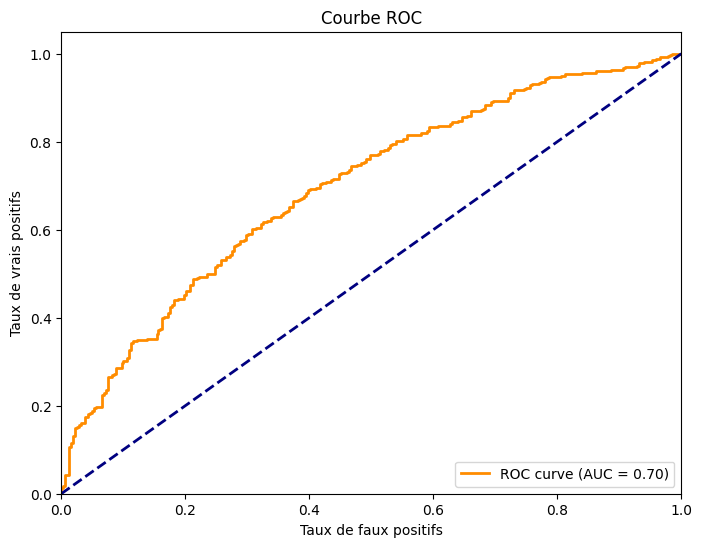

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Prédisez les probabilités des classes pour l'ensemble de test
y_score = model_LR.predict_proba(test_features)[:, 1]

# Calculez la courbe ROC
fpr, tpr, thresholds = roc_curve(test_labels, y_score)
roc_auc = auc(fpr, tpr)

# Tracez la courbe ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.title('Courbe ROC')
plt.legend(loc='lower right')
plt.show()

## ALpha = 0.02

In [ ]:
df=pd.read_csv("Alpha002Beta05.csv", sep="\t")

In [ ]:
df.shape

(3396, 247)

In [ ]:
df.head()

,exm1646-0_T_F_1921336671_2,exm3098-0_T_R_1919138216_2,exm-rs12741973-131_T_R_1990488294_1,exm14634-0_T_F_1919124801_2,exm2264834-0_T_F_1984844869_1,exm62679-0_T_F_1919183083_1,exm-rs2811893-131_T_R_1990490935_1,exm-rs4420065-131_T_R_1990492270_1,exm70490-0_T_R_1921347904_0,exm2268916-0_T_R_1984845784_1,...,exm2268596-0_T_F_1984849466_1,exm2268505-0_T_F_1984848912_1,exm2268506-0_T_F_1984849052_0,exm2263174-0_T_F_1975245093_0,exm2264790-0_T_F_1984849480_1,exm1653403-0_B_R_1922027060_1,exm-rs766420-131_T_F_1990494081_0,exm2273221-0_T_R_1984849351_0,exm1667836-0_B_F_1918598765_0,Smoking_status
0,1,1,1,1,0,0,1,0,0,1,...,0,0,1,1,0,0,1,0,0,0
1,1,1,1,1,0,1,0,0,1,1,...,0,0,0,0,0,0,1,1,0,1
2,0,0,1,1,1,0,1,1,1,0,...,0,0,1,0,0,0,1,0,0,1
3,0,1,0,1,1,0,1,0,0,1,...,0,0,0,0,0,0,1,0,0,0
4,0,1,0,0,0,0,1,0,1,0,...,0,1,0,1,0,1,0,0,1,1


In [ ]:
scaled_features = df.iloc[:, :-1]

labels=df.iloc[:, -1]

# Diviser les données en ensembles d'entraînement et de test
train_features, test_features, train_labels, test_labels = train_test_split(scaled_features, labels, test_size=0.2, random_state=42)

In [ ]:
model_LR=LogisticRegression(max_iter=10000, random_state=42)
model_LR.fit(train_features, train_labels)

# Prédire les labels pour l'ensemble de test
predictions = model_LR.predict(test_features)
# Calculer l'accuracy
accuracy = accuracy_score(test_labels, predictions)
print("Accuracy of Logistic Regression:", accuracy)

Accuracy of Logistic Regression: 0.7867647058823529


In [ ]:
# Calculer la précision
precision_LR = precision_score(test_labels, predictions, average='macro')
print("Precision Logistic Regression:", precision_LR)
# Calculer le rappel
recall_LR = recall_score(test_labels, predictions, average='macro')
print("Recall Logistic Regression:", recall_LR)
# Calculer le F1-score
f1_LR = f1_score(test_labels, predictions, average='macro')
print("F1-Score Logistic Regression:", f1_LR)

Precision Logistic Regression: 0.7861038961038962
Recall Logistic Regression: 0.7869510850215788
F1-Score Logistic Regression: 0.7863206187600094


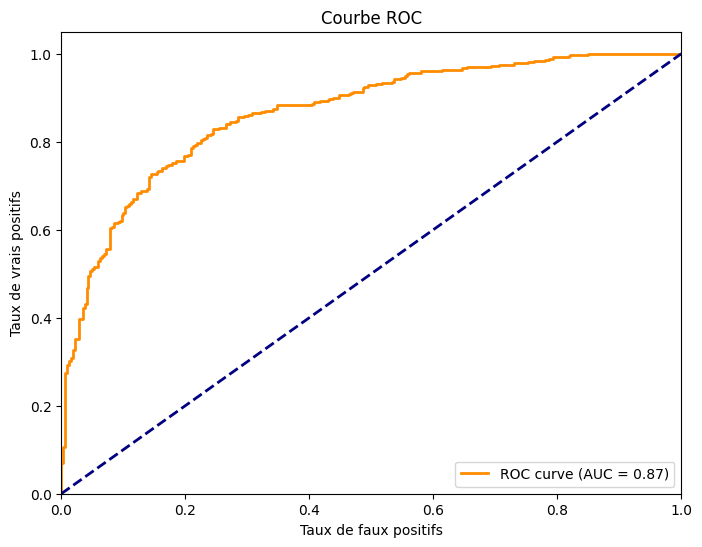

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Prédisez les probabilités des classes pour l'ensemble de test
y_score = model_LR.predict_proba(test_features)[:, 1]

# Calculez la courbe ROC
fpr, tpr, thresholds = roc_curve(test_labels, y_score)
roc_auc = auc(fpr, tpr)

# Tracez la courbe ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.title('Courbe ROC')
plt.legend(loc='lower right')
plt.show()

# Comparaison entre les meilleurs dataframes

Avec Logistic Regression

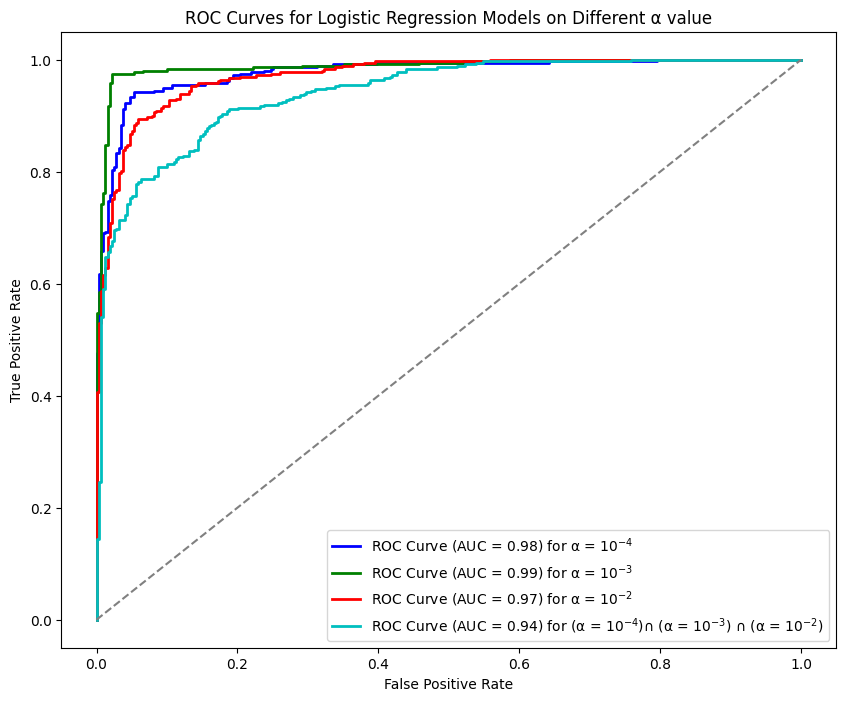

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc

# Charger les cinq dataframes (df1, df2, df3, df4, df5)
df1 = pd.read_csv("Alpha00001Beta05.csv", sep="\t")
df2 = pd.read_csv("Alpha0001Beta05.csv", sep="\t")
df3 = pd.read_csv("Alpha001Beta05.csv", sep="\t")
df4 = pd.read_csv("Intersection_699SNP.csv", sep="\t")

# Créer une liste de dataframes
dataframes = [df1, df2, df3, df4]
# Créer une liste de couleurs pour les courbes ROC
colors = ['b', 'g', 'r', 'c']

# Créer une liste de légendes mises à jour
legends = ['α = $10^{-4}$', 'α = $10^{-3}$', 'α = $10^{-2}$', '(α = $10^{-4}$)∩ (α = $10^{-3}$) ∩ (α = $10^{-2}$)']

# Préparer la figure
plt.figure(figsize=(10, 8))

# Boucle sur les dataframes
for i, df in enumerate(dataframes):
    # Séparer les caractéristiques et les étiquettes
    X = df.iloc[:, :-1]
    y = df.iloc[:, -1]


    # Diviser les données en ensembles d'entraînement et de test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Entraîner le modèle de régression logistique
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train, y_train)

    # Prédire les probabilités des classes positives (fumeurs)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Calculer le taux de faux positifs (FPR) et le taux de vrais positifs (TPR)
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)

    # Calculer l'aire sous la courbe ROC (AUC)
    roc_auc = auc(fpr, tpr)

    # Tracer la courbe ROC
    plt.plot(fpr, tpr, color=colors[i], lw=2, label='ROC Curve (AUC = %0.2f) for %s' % (roc_auc, legends[i]))

# Ajouter les étiquettes, la légende et le titre
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Logistic Regression Models on Different α value')
plt.legend(loc="lower right")

# Afficher le graphique
plt.show()

Avec SVM

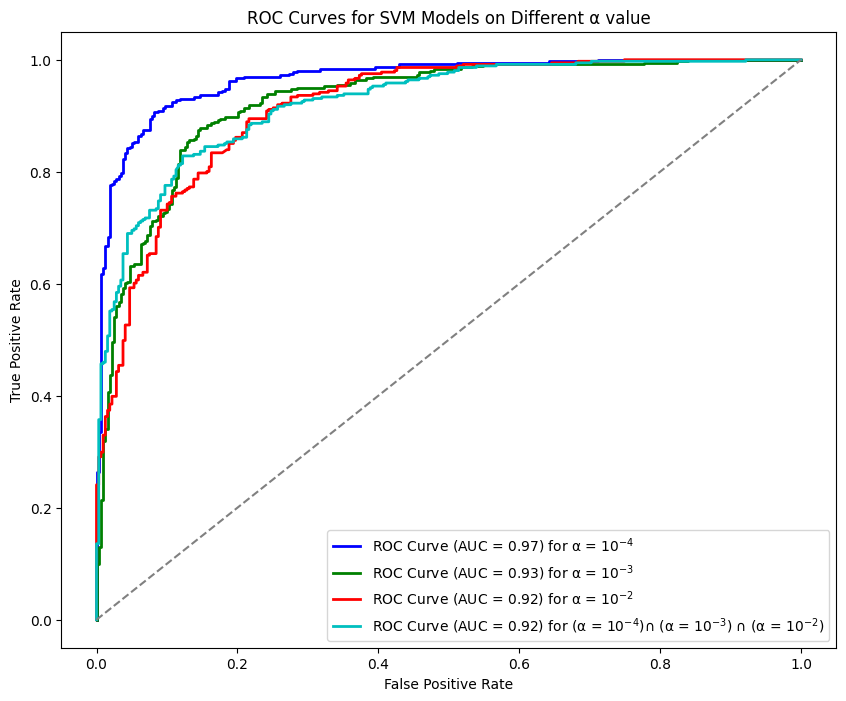

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc

# Charger les cinq dataframes (df1, df2, df3, df4, df5)
df1 = pd.read_csv("Alpha00001Beta05.csv", sep="\t")
df2 = pd.read_csv("Alpha0001Beta05.csv", sep="\t")
df3 = pd.read_csv("Alpha001Beta05.csv", sep="\t")
df4 = pd.read_csv("Intersection_699SNP.csv", sep="\t")

# Créer une liste de dataframes
dataframes = [df1, df2, df3, df4]
# Créer une liste de couleurs pour les courbes ROC
colors = ['b', 'g', 'r', 'c']

# Créer une liste de légendes mises à jour
legends = ['α = $10^{-4}$', 'α = $10^{-3}$', 'α = $10^{-2}$', '(α = $10^{-4}$)∩ (α = $10^{-3}$) ∩ (α = $10^{-2}$)']

# Préparer la figure
plt.figure(figsize=(10, 8))

# Boucle sur les dataframes
for i, df in enumerate(dataframes):
    # Séparer les caractéristiques et les étiquettes
    X = df.iloc[:, :-1]
    y = df.iloc[:, -1]


    # Diviser les données en ensembles d'entraînement et de test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Entraîner le modèle de SVM
    model = svm.SVC(kernel = "linear", probability=True, random_state=42)
    model.fit(X_train, y_train)

    # Prédire les probabilités des classes positives (fumeurs)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Calculer le taux de faux positifs (FPR) et le taux de vrais positifs (TPR)
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)

    # Calculer l'aire sous la courbe ROC (AUC)
    roc_auc = auc(fpr, tpr)

    # Tracer la courbe ROC
    plt.plot(fpr, tpr, color=colors[i], lw=2, label='ROC Curve (AUC = %0.2f) for %s' % (roc_auc, legends[i]))

# Ajouter les étiquettes, la légende et le titre
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for SVM Models on Different α value')
plt.legend(loc="lower right")

# Afficher le graphique
plt.show()

# Cross validation

Avec Logistic Regression

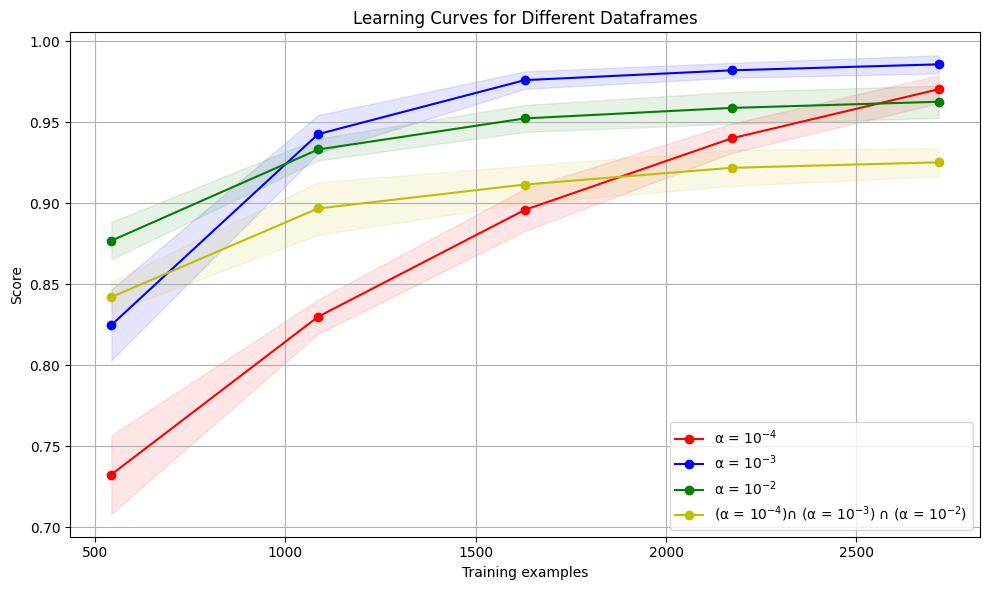

In [ ]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt

# Charger les cinq dataframes (df1, df2, df3, df4)
df1 = pd.read_csv("Alpha00001Beta05.csv", sep="\t")
df2 = pd.read_csv("Alpha0001Beta05.csv", sep="\t")
df3 = pd.read_csv("Alpha001Beta05.csv", sep="\t")
df4 = pd.read_csv("Intersection_699SNP.csv", sep="\t")

# Définir les tailles de l'ensemble d'entraînement à utiliser
train_sizes = [0.2, 0.4, 0.6, 0.8, 1]

# Créer une figure pour afficher les courbes d'apprentissage
plt.figure(figsize=(10, 6))

# Séparer les caractéristiques et les étiquettes pour chaque dataframe
dataframes = [(df1, 'r', 'α = $10^{-4}$'), (df2, 'b', 'α = $10^{-3}$'), (df3, 'g', 'α = $10^{-2}$'), (df4, 'y', '(α = $10^{-4}$)∩ (α = $10^{-3}$) ∩ (α = $10^{-2}$)')]

model_LR=LogisticRegression(max_iter=10000, random_state=42)
for df, color, label in dataframes:
    # Séparer les caractéristiques et les étiquettes pour ce dataframe
    X = df.drop(columns=['Smoking_status'])
    y = df['Smoking_status']

    # Calculer les scores d'apprentissage et de validation croisée pour ce dataframe
    train_sizes, _, valid_scores = learning_curve(model_LR, X, y, train_sizes=train_sizes, cv=5, scoring='roc_auc')

    # Calculer les moyennes et les écarts-types des scores pour ce dataframe
    valid_scores_mean = np.mean(valid_scores, axis=1)
    valid_scores_std = np.std(valid_scores, axis=1)

    # Tracer la courbe d'apprentissage pour ce dataframe
    plt.fill_between(train_sizes, valid_scores_mean - valid_scores_std, valid_scores_mean + valid_scores_std, alpha=0.1, color=color)
    plt.plot(train_sizes, valid_scores_mean, 'o-', color=color, label=label)

# Afficher la légende et la figure
plt.xlabel("Training examples")
plt.ylabel("Score")
plt.title("Learning Curves for Different Dataframes")
plt.legend(loc="best")
plt.grid(True)
plt.tight_layout()
plt.show()

Avec SVM

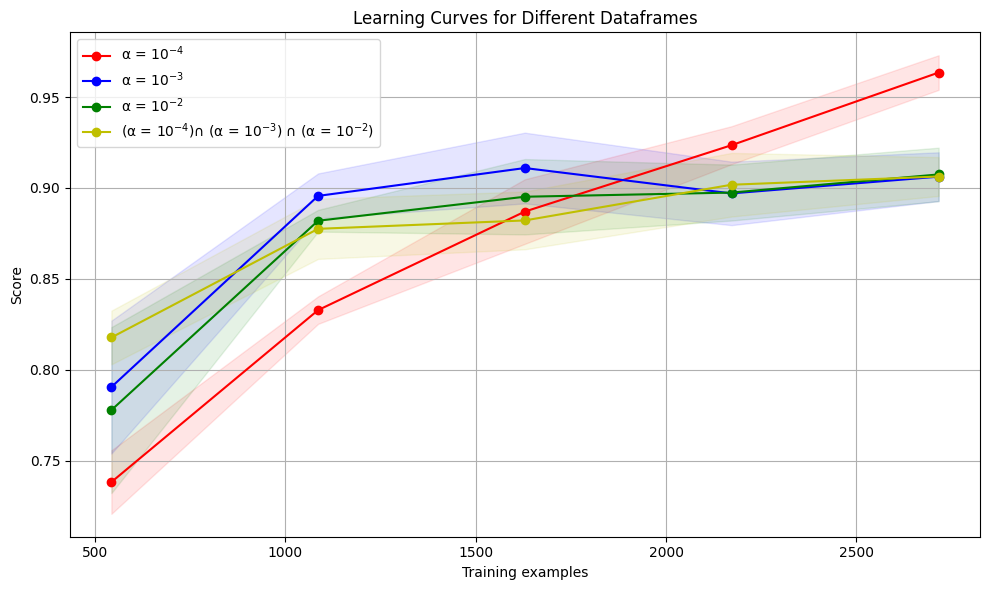

In [ ]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt

# Charger les cinq dataframes (df1, df2, df3, df4)
df1 = pd.read_csv("Alpha00001Beta05.csv", sep="\t")
df2 = pd.read_csv("Alpha0001Beta05.csv", sep="\t")
df3 = pd.read_csv("Alpha001Beta05.csv", sep="\t")
df4 = pd.read_csv("Intersection_699SNP.csv", sep="\t")

# Définir les tailles de l'ensemble d'entraînement à utiliser
train_sizes = [0.2, 0.4, 0.6, 0.8, 1]

# Créer une figure pour afficher les courbes d'apprentissage
plt.figure(figsize=(10, 6))

# Séparer les caractéristiques et les étiquettes pour chaque dataframe
dataframes = [(df1, 'r', 'α = $10^{-4}$'), (df2, 'b', 'α = $10^{-3}$'), (df3, 'g', 'α = $10^{-2}$'), (df4, 'y', '(α = $10^{-4}$)∩ (α = $10^{-3}$) ∩ (α = $10^{-2}$)')]

model = svm.SVC(kernel = "linear", probability=True, random_state=42)

for df, color, label in dataframes:
    # Séparer les caractéristiques et les étiquettes pour ce dataframe
    X = df.drop(columns=['Smoking_status'])
    y = df['Smoking_status']

    # Calculer les scores d'apprentissage et de validation croisée pour ce dataframe
    train_sizes, _, valid_scores = learning_curve(model, X, y, train_sizes=train_sizes, cv=5, scoring='roc_auc')

    # Calculer les moyennes et les écarts-types des scores pour ce dataframe
    valid_scores_mean = np.mean(valid_scores, axis=1)
    valid_scores_std = np.std(valid_scores, axis=1)

    # Tracer la courbe d'apprentissage pour ce dataframe
    plt.fill_between(train_sizes, valid_scores_mean - valid_scores_std, valid_scores_mean + valid_scores_std, alpha=0.1, color=color)
    plt.plot(train_sizes, valid_scores_mean, 'o-', color=color, label=label)

# Afficher la légende et la figure
plt.xlabel("Training examples")
plt.ylabel("Score")
plt.title("Learning Curves for Different Dataframes")
plt.legend(loc="best")
plt.grid(True)
plt.tight_layout()
plt.show()

# Heatmap

In [ ]:
df1=pd.read_csv("Chi2_test.txt")
df2=pd.read_csv("EN_Alpha00001Beta05.csv", sep="\t")
df3=pd.read_csv("EN_Alpha0001Beta05.csv", sep="\t")
df4=pd.read_csv("EN_Alpha001Beta05.csv", sep="\t")

In [ ]:
# Renommer la colonne 'Feature' en 'SNPs'
df1.rename(columns={'Feature': 'Best_Chi2_score'}, inplace=True)

In [ ]:
# Concaténer les dataframes le long de l'axe des colonnes
merged_df = pd.concat([df1, df2, df3, df4], axis=1)

In [ ]:
merged_df.head()

,Best_Chi2_score,Apha00001Beta05,Alpha0001Beta05,Alpha001Beta05
0,exm908706-0_T_R_1918250194_0,exm2264981-0_T_F_1984844725_1,exm1646-0_T_F_1921336671_0,exm1646-0_T_F_1921336671_2
1,exm713312-0_T_F_1922967753_2,exm1312-0_T_F_1919180959_2,exm2062-0_B_R_1919120138_1,exm3098-0_T_R_1919138216_2
2,exm1649435-0_T_R_1922087680_1,exm1646-0_T_F_1921336671_0,exm3098-0_T_R_1919138216_2,exm7145-0_T_R_1921364544_2
3,exm1667836-0_B_F_1918598765_2,exm1646-0_T_F_1921336671_2,exm4691-0_T_R_1921404998_1,exm7551-0_T_R_1921491574_1
4,exm2264790-0_T_F_1984849480_1,exm1909-0_T_F_1919142595_2,exm4691-0_T_R_1921404998_2,exm-rs12741973-131_T_R_1990488294_1


In [ ]:
import re

# Fonction pour supprimer les caractères après le tiret "-" sauf s'il est suivi par "r"
def remove_chars(s):
    if isinstance(s, str):
        return re.sub(r'-(?![r])[^ ]*', '', s)
    else:
        return s

# Appliquer la fonction à chaque élément du dataframe
merged_df = merged_df.applymap(remove_chars)

In [ ]:
merged_df.head()

,Best_Chi2_score,Apha00001Beta05,Alpha0001Beta05,Alpha001Beta05
0,exm908706,exm2264981,exm1646,exm1646
1,exm713312,exm1312,exm2062,exm3098
2,exm1649435,exm1646,exm3098,exm7145
3,exm1667836,exm1646,exm4691,exm7551
4,exm2264790,exm1909,exm4691,exm-rs12741973


In [ ]:
# Concaténer toutes les colonnes du DataFrame merged_df en une seule série
all_words = pd.concat([merged_df[col] for col in merged_df.columns])

# Obtenir une liste de mots uniques
unique_words = all_words.unique()

In [ ]:
len(unique_words)

6625

In [ ]:
# Créer le DataFrame final_df à partir de la liste unique_words
final_df = pd.DataFrame(unique_words, columns=['SNPs'])

# Parcourir chaque colonne du DataFrame merged_df
for col in merged_df.columns:
    # Ajouter une nouvelle colonne au DataFrame final_df
    final_df[col] = final_df['SNPs'].apply(lambda word: 1 if word in merged_df[col].values else 0)


In [ ]:
final_df.head()

,SNPs,Best_Chi2_score,Apha00001Beta05,Alpha0001Beta05,Alpha001Beta05
0,exm908706,1,0,1,1
1,exm713312,1,1,1,1
2,exm1649435,1,1,1,1
3,exm1667836,1,1,0,0
4,exm2264790,1,0,1,1


In [ ]:
final_df.to_csv("df_heatmap.csv", sep="\t", index=False)

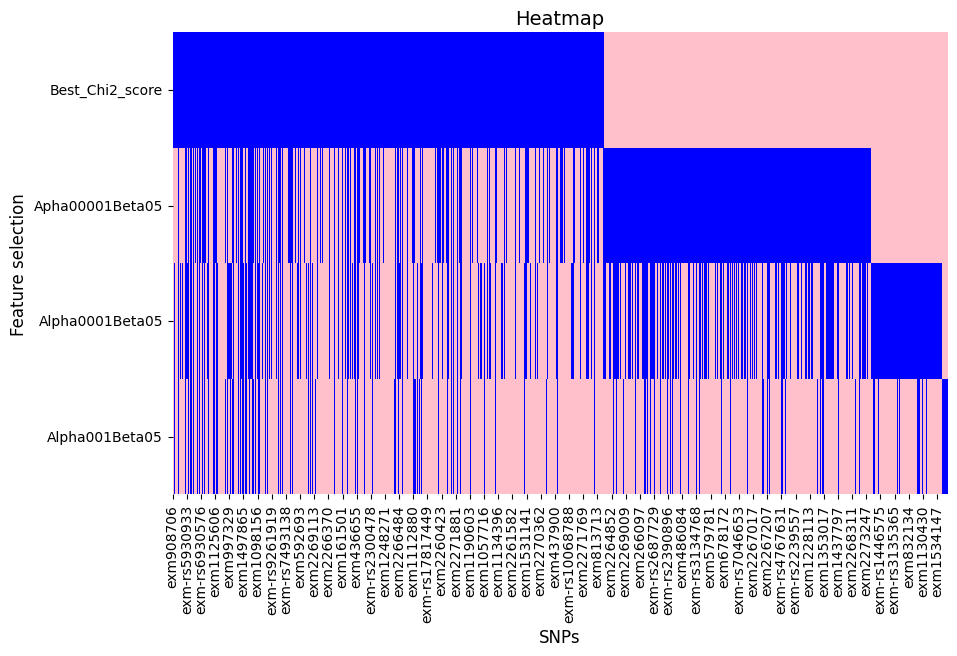

In [ ]:
import seaborn as sns

# Transposer le DataFrame pour avoir les mots en abscisse
final_df_transposed = final_df.set_index('SNPs').T

# Spécifiez les couleurs à utiliser pour le heatmap
colors = ["#FFC0CB", "#0000FF"]  # Rose et Bleu

# Créer le heatmap
plt.figure(figsize=(10, 6))
heatmap = sns.heatmap(final_df_transposed, cmap=sns.color_palette(colors), cbar=False)

# Réglages supplémentaires du graphique
heatmap.set_xlabel('SNPs', fontsize=12)
heatmap.set_ylabel('Feature selection', fontsize=12)
heatmap.set_title('Heatmap', fontsize=14)

# Afficher le heatmap
plt.show()

In [ ]:
df_hole_exome=pd.read_csv("HumanExome-12v1_A_Gene_Annotation_sorted.txt", sep="\t")

<ipython-input-54-79971bd26870>:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df_hole_exome=pd.read_csv("HumanExome-12v1_A_Gene_Annotation_sorted.txt", sep="\t")


In [ ]:
df_hole_exome.head()

,Name,Chr,MapInfo,Alleles,Transcript(s),Gene(s),in Exon,Mutation(s)
0,exm1000006,12,49446040,[T/C],NM_003482,MLL2,EXON,Missense_A476T
1,exm1000025,12,49446800,[A/G],NM_003482,MLL2,EXON,Missense_S337L
2,exm1000032,12,49447304,[T/C],NM_003482,MLL2,EXON,Missense_R265H
3,exm1000038,12,49447881,[A/G],NM_003482,MLL2,EXON,Missense_R185C
4,exm1000050,12,49448463,[T/C],NM_003482,MLL2,EXON,Missense_R83Q


In [ ]:
df_hole_exome.rename(columns={'Name': 'SNPs'}, inplace=True)

In [ ]:
annotation = final_df.merge(df_hole_exome, how='inner', left_on='SNPs', right_on='SNPs')

In [ ]:
annotation.shape

(6623, 12)

In [ ]:
annotation.to_csv("Annotation_heatmap.csv", sep="\t", index=False)

# Les SNPs présents partout

In [ ]:
# Sélectionner uniquement les lignes où toutes les colonnes, sauf la colonne "Words", ont la valeur 1
filtered_df = final_df[final_df.iloc[:, 1:].all(axis=1)]

# Extraire les mots de la colonne "Words" dans une liste
words_list = filtered_df['SNPs'].tolist()

In [ ]:
filtered_df.shape

(448, 5)

In [ ]:
filtered_df.head()

,SNPs,Best_Chi2_score,Apha00001Beta05,Alpha0001Beta05,Alpha001Beta05
1,exm713312,1,1,1,1
2,exm1649435,1,1,1,1
6,exm302436,1,1,1,1
18,exm1645729,1,1,1,1
19,exm2273246,1,1,1,1


In [ ]:
df_699_Intersection = pd.read_csv("Intersection_699SNP.csv", sep="\t")

In [ ]:
df_699_Intersection.shape

(3396, 700)

In [ ]:
# Sélectionner les colonnes de df_699_Intersection qui contiennent des mots de words_list
selected_columns = df_699_Intersection.filter(regex='|'.join(words_list))

In [ ]:
selected_columns["Smoking_status"]=df_699_Intersection["Smoking_status"]

<ipython-input-88-a1950855c8c8>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_columns["Smoking_status"]=df_699_Intersection["Smoking_status"]


In [ ]:
selected_columns.shape

(3396, 420)

In [ ]:
selected_columns.head()

,exm2261464-0_T_F_1975260898_1,exm1537001-0_T_F_1922596323_0,exm1244963-0_T_F_1921680259_0,exm-rs7590720-131_T_F_1990494022_0,exm1125198-0_T_F_1922791349_1,exm2270315-0_T_R_1984847795_2,exm2249017-0_T_F_1975249026_2,exm2266455-0_T_F_1984840983_0,exm2258958-0_T_F_1975264740_1,exm2269235-0_T_R_1984842922_2,...,exm1476951-0_B_R_1923161142_2,exm-rs2816316-131_T_R_1990490941_0,exm259476-0_T_R_1918940960_2,exm-rs11249661-131_T_F_1990487609_2,exm2271097-0_T_R_1984851205_2,exm2265146-0_T_F_1984842999_0,exm7551-0_T_R_1921491574_1,exm2264518-0_T_F_1984847007_0,exm928087-0_T_F_1918386921_2,Smoking_status
0,0,0,1,0,1,1,1,1,1,1,...,1,0,0,1,0,1,1,0,0,0
1,0,0,1,1,0,0,1,0,1,0,...,1,0,1,1,0,0,1,0,1,1
2,0,0,0,0,1,0,0,0,0,0,...,1,0,1,1,1,0,0,0,0,1
3,0,0,0,1,0,0,0,1,1,0,...,1,0,0,0,0,0,1,0,0,0
4,0,0,0,1,1,0,0,0,1,0,...,1,0,0,1,0,1,0,0,1,1


In [ ]:
scaled_features = selected_columns.iloc[:, :-1]

labels=selected_columns.iloc[:, -1]

# Diviser les données en ensembles d'entraînement et de test
train_features, test_features, train_labels, test_labels = train_test_split(scaled_features, labels, test_size=0.2, random_state=42)

In [ ]:
model_LR=LogisticRegression(max_iter=10000, random_state=42)
model_LR.fit(train_features, train_labels)

# Prédire les labels pour l'ensemble de test
predictions = model_LR.predict(test_features)
# Calculer l'accuracy
accuracy = accuracy_score(test_labels, predictions)
print("Accuracy of Logistic Regression:", accuracy)

Accuracy of Logistic Regression: 0.7485294117647059


In [ ]:
# Calculer la précision
precision_LR = precision_score(test_labels, predictions, average='macro')
print("Precision Logistic Regression:", precision_LR)
# Calculer le rappel
recall_LR = recall_score(test_labels, predictions, average='macro')
print("Recall Logistic Regression:", recall_LR)
# Calculer le F1-score
f1_LR = f1_score(test_labels, predictions, average='macro')
print("F1-Score Logistic Regression:", f1_LR)

Precision Logistic Regression: 0.7485294117647059
Recall Logistic Regression: 0.7494811521461631
F1-Score Logistic Regression: 0.7482893503536028


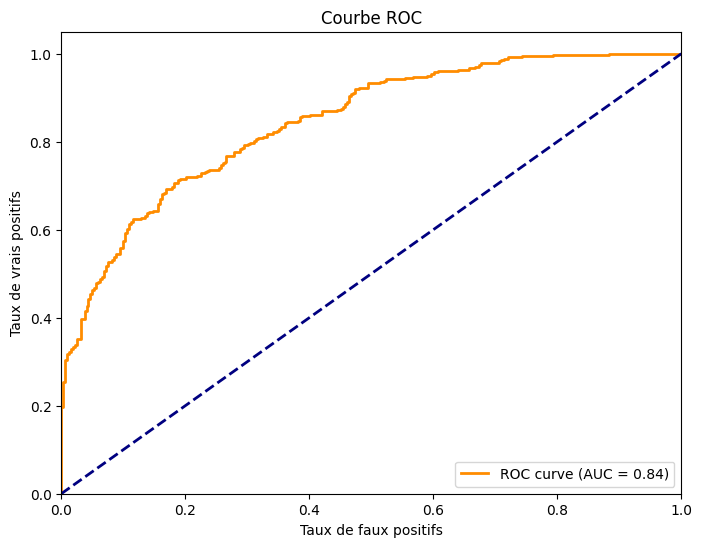

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Prédisez les probabilités des classes pour l'ensemble de test
y_score = model_LR.predict_proba(test_features)[:, 1]

# Calculez la courbe ROC
fpr, tpr, thresholds = roc_curve(test_labels, y_score)
roc_auc = auc(fpr, tpr)

# Tracez la courbe ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.title('Courbe ROC')
plt.legend(loc='lower right')
plt.show()

# Smokings gene's

In [ ]:
# Ouvrir le fichier texte en mode lecture
with open("SNPs_selected.txt", "r") as file:
    # Lire chaque ligne du fichier
    lines = file.readlines()

    # Initialiser une liste pour stocker les mots
    word_list = []

    # Parcourir chaque ligne du fichier
    for line in lines:
        # Diviser la ligne en mots en utilisant l'espace comme séparateur
        words = line.split()

        # Ajouter chaque mot à la liste des mots
        word_list.extend(words)

In [ ]:
import pandas as pd

# Supposons que df est votre DataFrame d'origine
# Supposons également que word_list est votre liste de noms de colonnes extraits

# Créer un nouveau DataFrame avec les colonnes extraites
new_df = df.loc[:, word_list]

# Afficher le nouveau DataFrame
print(new_df)

Combinés avec les 700 SNPs

# Les fréquences de SNPs,Genes

In [ ]:
import pandas as pd

# Création d'un dataframe de démonstration
data = {'SNP': ['SNP1', 'SNP2', 'SNP3', 'SNP4', 'SNP5'],
        'Genes': ['GeneA', 'GeneB', 'GeneA', 'GeneC', 'GeneB']}
df = pd.DataFrame(data)

# Groupement des SNP par gène et comptage du nombre de SNP
grouped = df.groupby('Genes')['SNP'].agg([('SNP', ' '.join), ('Nbre de SNP', 'count')]).reset_index()

# Renommer les colonnes
grouped.columns = ['Genes', 'SNP', 'Nbre de SNP']

# Afficher le nouveau dataframe
print(grouped)

   Genes        SNP  Nbre de SNP
0  GeneA  SNP1 SNP3            2
1  GeneB  SNP2 SNP5            2
2  GeneC       SNP4            1


In [ ]:
df = pd.read_csv("Annotation_699_exm_KEGG_sans_occ_sorted.csv", sep='\t')

In [ ]:
df.head()

,Name,Chr,MapInfo,Alleles,Transcript(s),Gene(s),in Exon,Mutation(s)
0,exm-rs10074258,5,106982560,[T/C],NM_001962,EFNA5,NaN,Silent
1,exm-rs10496166,2,69063909,[A/G],NaN,NaN,NaN,NaN
2,exm-rs1055055,1,42880516,[T/C],NM_173642,RIMKLA,EXON,Synonymous_S349S
3,exm-rs1064395,19,19361735,[A/G],NM_004386,NCAN,EXON,Silent
4,exm-rs10776612,10,49735563,[T/C],"NM_001256027,NR_045675,NM_021226,NM_001256025,...","ARHGAP22,ARHGAP22,ARHGAP22,ARHGAP22,ARHGAP22",NaN,"Silent,Silent,Silent,Silent,Silent"


In [ ]:
df=df[["Name", "Gene(s)"]]

In [ ]:
df.head()

,Name,Gene(s)
0,exm-rs10074258,EFNA5
1,exm-rs10496166,NaN
2,exm-rs1055055,RIMKLA
3,exm-rs1064395,NCAN
4,exm-rs10776612,"ARHGAP22,ARHGAP22,ARHGAP22,ARHGAP22,ARHGAP22"


In [ ]:
# Groupement des SNP par gène et comptage du nombre de SNP
grouped = df.groupby('Gene(s)')['Name'].agg([('Name', ' '.join), ('Nbre de SNP', 'count')]).reset_index()

# Renommer les colonnes
grouped.columns = ['Gene(s)', 'Name', 'Nbre de SNP']

In [ ]:
# Tri du dataframe en fonction du nombre de SNP
grouped = grouped.sort_values(by='Nbre de SNP', ascending=False)

# Réinitialiser les index après le tri
grouped = grouped.reset_index(drop=True)

In [ ]:
grouped.head()

,Gene(s),Name,Nbre de SNP
0,GRIN3A,exm2179600 exm2259057 exm767992 exm767994 exm7...,29
1,GRIN3B,exm1398312 exm1398316 exm1398342 exm1398358 ex...,27
2,"CACNA1A,CACNA1A,CACNA1A,CACNA1A,CACNA1A",exm1432879 exm1432906 exm1432914 exm1432921 ex...,25
3,GRIN2C,exm1352435 exm1352436 exm1352442 exm1352445 ex...,23
4,"CACNA1B,CACNA1B",exm2247915 exm2264375 exm2274390 exm804488 exm...,23


In [ ]:
grouped.to_csv("FrequenceGenesSNP.csv", sep='\t')

In [ ]:
import pandas as pd

# Exemple de données
data = {'Colonne1': ['ABC-123-456', 'XYZ-789-rs123-abc', 'DEF-456-rs987-test', 'GHI-rs321']}
df = pd.DataFrame(data)

# Fonction pour supprimer les caractères après le premier '-' en fonction de la présence de 'rs'
def supprimer_caracteres(cellule):
    if 'rs' in cellule:
        # Si 'rs' est présent, rechercher le premier '-' après 'rs'
        pos_rs = cellule.find('rs')
        pos_dash = cellule.find('-', pos_rs)
        if pos_dash != -1:
            return cellule[:pos_dash]
        else:
            return cellule
    else:
        # Si 'rs' n'est pas présent, supprimer les caractères après le premier '-'
        pos_dash = cellule.find('-')
        if pos_dash != -1:
            return cellule[:pos_dash]
        else:
            return cellule

# Appliquer la fonction à la première colonne du DataFrame
df['Colonne1'] = df['Colonne1'].apply(supprimer_caracteres)

# Afficher le DataFrame résultant
print(df)

        Colonne1
0            ABC
1  XYZ-789-rs123
2  DEF-456-rs987
3      GHI-rs321


In [ ]:
df_freq= pd.read_csv("Frequence_Only.csv", sep="\t")

In [ ]:
df_freq['Name'] = df_freq['Name'].apply(supprimer_caracteres)

In [ ]:
join= pd.merge(df, df_freq, on = "Name", how='inner')

In [ ]:
join.shape

(1161, 3)

In [ ]:
join.head()

,Name,Gene(s),Frequence
0,exm-rs10074258,EFNA5,3188
1,exm-rs10496166,NaN,2837
2,exm-rs1055055,RIMKLA,2649
3,exm-rs1064395,NCAN,2685
4,exm-rs10776612,"ARHGAP22,ARHGAP22,ARHGAP22,ARHGAP22,ARHGAP22",2211


In [ ]:
# Fonction pour garder le premier mot avant la virgule
def garder_premier_mot(cellule):
  if pd.isna(cellule):
        return cellule
  # Diviser la chaîne de caractères en une liste de mots à l'aide de split(',')
  mots = cellule.split(',')
  # Retourner le premier mot de la liste
  return mots[0]

# Appliquer la fonction à la colonne 'Gene(s)'
join['Gene(s)'] = join['Gene(s)'].apply(garder_premier_mot)

In [ ]:
join.head()

,Name,Gene(s),Frequence
0,exm-rs10074258,EFNA5,3188
1,exm-rs10496166,NaN,2837
2,exm-rs1055055,RIMKLA,2649
3,exm-rs1064395,NCAN,2685
4,exm-rs10776612,ARHGAP22,2211


In [ ]:
import pandas as pd

# Exemple de données
data = {'SNP': ['SNP1', 'SNP2', 'SNP3', 'SNP4', 'SNP5'],
        'Gene(s)': ['GeneA', 'GeneB', 'GeneA', 'GeneC', 'GeneB'],
        'Frequence': [0.1, 0.2, 0.3, 0.4, 0.5]}
df = pd.DataFrame(data)

# Renommer la colonne 'SNP' en 'Nbre de SNP'
df = df.rename(columns={'SNP': 'Nbre de SNP'})

# Groupement des données par gène et agrégation des SNP et des fréquences
grouped = df.groupby('Gene(s)').agg({'Nbre de SNP': 'size',
                                      'Frequence': 'sum',
                                      'Nbre de SNP': lambda x: ', '.join(x)}).reset_index()

# Renommer les colonnes
grouped.columns = ['Genes', 'SNP', 'Frequence',]

# Afficher le nouveau dataframe
print(grouped)

   Genes         SNP  Frequence
0  GeneA  SNP1, SNP3        0.4
1  GeneB  SNP2, SNP5        0.7
2  GeneC        SNP4        0.4


In [ ]:
# Groupement des données par gène et agrégation des SNP et des fréquences
grouped = join.groupby('Gene(s)').agg({'Name': 'size',
                                      'Frequence': 'sum',
                                      'Name': lambda x: ', '.join(x)}).reset_index()

# Renommer les colonnes
grouped.columns = ['Genes', 'SNP', 'Frequence']

# Tri du dataframe en fonction du nombre de SNP
grouped = grouped.sort_values(by='Frequence', ascending=False)

# Réinitialiser les index après le tri
grouped = grouped.reset_index(drop=True)

In [ ]:
grouped.head()

,Genes,SNP,Frequence
0,GRIN3A,"exm2179600, exm2259057, exm767992, exm767994, ...",97596
1,GRIN3B,"exm1398312, exm1398316, exm1398342, exm1398358...",87904
2,GRIN2C,"exm1352435, exm1352436, exm1352442, exm1352445...",78142
3,CACNA1A,"exm1432879, exm1432906, exm1432914, exm1432921...",75538
4,MAML1,"exm509882, exm509883, exm509887, exm509891, ex...",67979


In [ ]:
# Compter le nombre de SNP dans chaque ligne et créer une nouvelle colonne "Nbre de SNP"
grouped['Nbre de SNP'] = grouped['SNP'].str.count(', ') + 1

In [ ]:
grouped.head()

,Genes,SNP,Frequence,Nbre de SNP
0,GRIN3A,"exm2179600, exm2259057, exm767992, exm767994, ...",97596,32
1,GRIN3B,"exm1398312, exm1398316, exm1398342, exm1398358...",87904,27
2,GRIN2C,"exm1352435, exm1352436, exm1352442, exm1352445...",78142,23
3,CACNA1A,"exm1432879, exm1432906, exm1432914, exm1432921...",75538,25
4,MAML1,"exm509882, exm509883, exm509887, exm509891, ex...",67979,22


In [ ]:
grouped.to_csv("Frequence_Genes.csv", sep="\t", index=False)

In [ ]:
df_uniprot = pd.read_csv("FréquencesGenesSNP.csv", sep="\t")

FileNotFoundError: [Errno 2] No such file or directory: 'FréquencesGenesSNP.csv'

# Hyena

https://discuss.tensorflow.org/t/implementing-hyena-models-in-keras/19188

In [ ]:
from transformers import pipeline
!pip install keras_nlp

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 415.4/415.4 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 8.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 15.5 MB/s eta 0:00:00


In [ ]:
import keras
import keras_nlp
import tensorflow

def convolve(x,y):
    xT = tensorflow.transpose(x,[0,2,1])
    yT = tensorflow.transpose(y,[0,2,1])
    z = tensorflow.signal.irfft(tensorflow.signal.rfft(xT)*tensorflow.signal.rfft(yT))
    return tensorflow.transpose(z,[0,2,1])




class HyenaLayer(keras.layers.Layer):
    """Keras implementation of Hyena layer. Unlike in the original paper,
       this can be used as an encoder layer by setting the optional parameter
       `causal` to `False`"""

    def __init__(self,stages=3,causal=True):
        """


        Parameters
        ----------
        stages : int, optional
            Number of stages of convolution and Hadamard multiplication. The default is 3.
        causal : bool, optional
            Set to False for an encoder layer. The default is True.

        Returns
        -------
        None.

        """
        super(HyenaLayer,self).__init__()
        self.stages = stages
        self.causal = causal
        self.data_projection = None
        self.filters = None
        self.positional_encoding = keras_nlp.layers.SinePositionEncoding()

    def build(self,input_shape):
        width = input_shape[-1]
        self.data_projection = self.add_weight(shape=(width,width,self.stages+1),
                                               trainable=True)
        self.filters = self.add_weight(shape=(width,width,self.stages),
                                       trainable=True)

    def call(self,X,training=None):
        x = tensorflow.tensordot(X,self.data_projection,axes=1)
        f = tensorflow.tensordot(self.positional_encoding(X),self.filters,axes=1)
        if self.causal:
            concat = keras.layers.Concatenate()
            x = concat(x,tensorflow.zeros_like(x))
            f = concat(f,tensorflow.zeros_like(f))
        y = x[:,:,:,0]
        for i in range(self.stages):
            y = convolve(y,f[:,:,:,i])*x[:,:,:,i+1]
        if self.causal:
            for (i,n) in enumerate(X.row_lengths()):
                y[i] = y[i,:n]
        return y

Using TensorFlow backend
